## RAPTOR: Recursive Abstractive Processing for Tree Organized Retrieval - Retrieval with Recursive Summaries

This notebook contains brief discussion and explanation of the Paper called **RAPTOR: Recursive Abstractive Processing for Tree Organized Retrieval**. 
<p>Chunking is a key step in Retrieval Augmented Generation. Chunking is the process of breaking large documents into smaller, manageable text segments (chunks) before embedding. Embedding models and LLMs have strict limits on how much text they can process at once. Chunking ensures that individual text pieces comfortably fit within these boundaries.</p>

<p>Most of the existing Retrieval Augmented Language Model retrieve only chunks from a Retrieval Corpus that limits the holistic understanding of the overall document context.</p>

<p>RAPTOR introduces a novel approach of recursively embed, cluster and summarize chunks of text from the corpus constructing a tree with different levels of summarization.</p>

<p>RAPTOR through its retrieval strategies with recursive summaries offers significant improvements over traditional retrieval strategies</p>


### Objective
===========

Large Language Models have demonstrated impressive performance on many tasks, yet lacks sufficient domain specific knowledge for particular tasks hence requiring integration of domain knowledge. Contemporary retrieval strategies rely on the short, coniguous text chunks which is a limiting strategy as it fails to leverage the overall, macro-level organization of a text or conversation, mapping out how major ideas, paragraphs, or arguments relate to one another to create a cohesive whole. The top-k retrieved short contiguous texts will not contain enough context to answer thematic questions that require synthesis of knowledge from multiple parts of the text.
<p>RAPTOR adopts a three stage bottom-up approch involving Clustering document chunks, Generating a summary of those chunks and then repeat this process to create a document tree from bottom-up.</p>

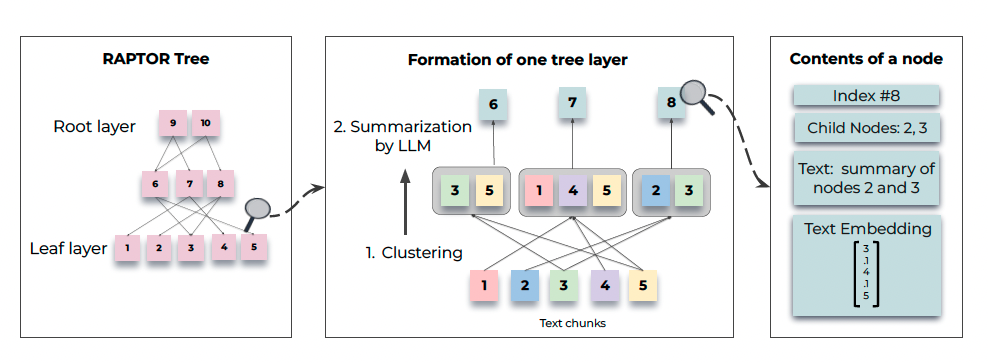

Figure 1: **Tree construction process**: RAPTOR recursively clusters chunks of text based on their
vector embeddings and generates text summaries of those clusters, constructing a tree from the
bottom up. Nodes clustered together are siblings; a parent node contains the text summary of that
cluster.

### Contribution
============
<p>The main contribution of the paper is the idea of using text summarization to allow retrieval augmentation of context at different scales, and to show its effectiveness in experiments on collections of long documents.</p>
<p>Controlled experiments with three language models (UnifiedQA (Khashabi et al., 2020),
GPT-3 (Brown et al., 2020) and GPT-4 (OpenAI, 2023)) show that RAPTOR outperforms current
retrieval augmentation. Moreover, RAPTOR coupled with GPT-4, and sometimes even with UnifiedQA,
gives new state-of-the-art results on three QA tasks: free text response questions on books
and movies (NarrativeQA, Koˇcisk`y et al. 2018), full-text NLP papers (QASPER, Dasigi et al. 2021),
and multiple-choice questions based on medium-length passages (QuALITY, Pang et al. 2022).</p>

### Methods
========
<p>RAPTOR segments the retrieval corpus into short, contiguous texts of length 100. If the sentence exceeds the 100 token limit, the entire sentence is moved to the next chunk. As the sentence is not cut in the middle of the sentence, this preserves the contextual and semantic coherence of the text within each chunk. The chunks are then embedded with SBERT, which is a BERT based encoder. The chunks and their corresponding SBERT embeddings form the leaf nodes of our tree structure.</p>
<p>A clustering algorithm is applied to group all the similar chunks.</p>
<p>A Language model is used to summarize the grouped texts. These summarized texts are re-embedded and the cycle of embedding, clustering and summarization continues until further clustering becomes infeasible.</p>
<p>Two distinct strategies are applied during the inference time such as Tree Traversal and Collapse Tree.</p>
<p>Clustering Algorithm of RAPTOR is based on Gaussian Mixture Models (GMMs) that the datapoints are generated from a mixture of sevaral Gaussian distribution.</p>

#### Gaussian Distribution 
Given a set of N text segments, each represented as a d-dimensional dense vector embedding, the
likelihood of a text vector, x, given its membership in the kth Gaussian distribution, is denoted by
$P(x|k) = N(x; μk,P Σk)$. The overall probability distribution is a weighted combination $P(x) = \sum_{k=1}^K π_kN(x; μk,Σk)$, where $πk$ signifies the mixture weight for the $kth$ Gaussian distribution.

#### Uniform Manifold Approximation and Projection
<p>To handle the Higher Dimensonality of Vector Embeddings a Uniform Manifold Approximation and Projection manifold learning technique for dimensionality reduction has been applied.</p>

#### Bayesian Information Criterion
<p>Bayesian Information Criterion has been employed in order to determine the optimal number of clusters.</p>

#### Model Based Summarization
<p>gpt-3.5-turbo model has been used for the summarization tasks.</p>

#### Querying
<p>Two querying mechanism has been employed by RAPTOR such as Tree Traversal and Collapse Tree.The tree traversal method first selects the top-k most relevant root nodes based on their cosine
similarity to the query embedding. The children of these selected nodes are considered at the next
layer and the top-k nodes are selected from this pool again based on their cosine similarity to the
query vector.</p>
<p>The collapsed tree approach offers a simpler way to search for relevant information by considering
all nodes in the tree simultaneously.</p>

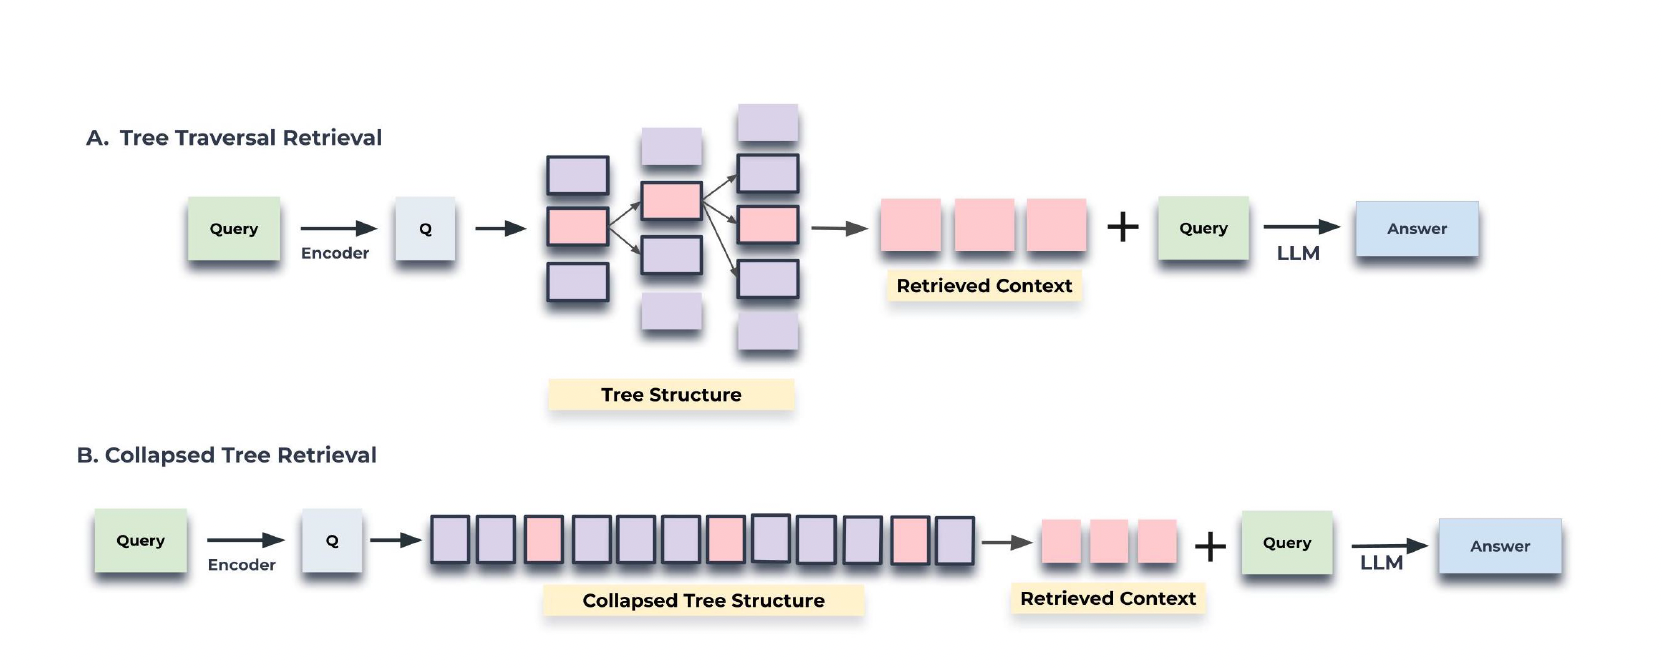

### Experiments
=============
#### Datasets
<p>RAPTOR's performance has been measured scross three Question-Answering datasets. NarrativeQA, QASPER and QuALITY.</p>

#### Controlled Baseline Comparisons
<p>Several controlled comparisons are conducted using the UnifiedQA, NarrativeQA, QuALITY and QASPER with or without RAPTOR</p>
<p>Since RAPTOR with SBERT has the best performance and is subsequently compared with BM25 and DPR, using three different LLMs: GPT-3, GPT-4, and UnifiedQA. RAPTOR consistently outperforms BM25 and DPR across all three Language Models on the QASPER dataset. RAPTOR’s F-1 Match scores are 53.1%, 55.7%, and 36.6% when using GPT-3, GPT-4, and UnifiedQA, respectively. These scores surpass DPR by
margins of 1.8, 2.7, and 4.5 points, and outdo BM25 by 6.5, 5.5, and 10.2 points across the respective LLMs.</p>

### Code
======
#### RAPTOR Tree Builder
<p>This file implements the logic for building a hierarchical tree of text summaries from a long input document. The idea is to chunk text, embed the chunks, group related chunks together, summarize each group, and repeat this process layer by layer — creating a tree where the leaves are raw text and the higher nodes are increasingly abstract summaries.</p>

**create_node(self, index, text, children_indices=None) -> Tuple[int, Node]**
<p>Builds a single tree Node. If no children_indices is given, it starts with an empty set. It computes an embedding for text using every model in self.embedding_models then constructs and returns the Node and the index.</p>

**create_embedding(self, text) -> List[float]**
<p>A thin convenience wrapper around the single embedding model designated by self.cluster_embedding_model.</p>

**summarize(self, context, max_tokens=150) -> str**
<p>Delegates to self.summarization_model.summarize(context, max_tokens) to turn a block of text into a shorter summary.</p>

**get_relevant_nodes(self, current_node, list_nodes) -> List[Node]**
Finds which nodes in list_nodes are most similar to current_node:
- Gathers embeddings for all candidate nodes using the get_embeddings() method.
- Computes cosine distances between current_node's embedding and each candidate by invoking distances_from_embeddings()
- Ranks nodes by closeness with indices_of_nearest_neighbors_from_distances(...)
- Filters the ranked list based on selection_mode: either keeps anything above self.threshold, or just takes the top self.top_k
- Returns the actual Node objects corresponding to the selected indices

**multithreaded_create_leaf_nodes(self, chunks: List[str]) -> Dict[int, Node]**
Parallelizes leaf-node creation. 
- Submits a create_node(index, text) task per chunk to a ThreadPoolExecutor, then collects results as they complete into a {index: Node} dictionary.
- This speeds things up since each create_node call involves an API request to an embedding model.

**build_from_text(self, text: str, use_multithreading: bool = True) -> Tree**
The main public entry point for building a tree from raw text:
- Splits text into token-bounded chunks by invoking **split_text(text, self.tokenizer, self.max_tokens)**
- Creates leaf nodes from those chunks — either in parallel (multithreaded_create_leaf_nodes) or sequentially in a loop
- Stores those leaf nodes as Layer 0 in layer_to_nodes
- Deep-copies the leaf nodes into all_nodes
- Calls self.construct_tree() to build all the higher layers

In [ ]:
def create_node(
        self, index: int, text: str, children_indices: Optional[Set[int]] = None
    ) -> Tuple[int, Node]:
    """Creates a new node with the given index, text, and (optionally) children indices.

    Args:
        index (int): The index of the new node.
        text (str): The text associated with the new node.
        children_indices (Optional[Set[int]]): A set of indices representing the children of the new node.
            If not provided, an empty set will be used.

    Returns:
        Tuple[int, Node]: A tuple containing the index and the newly created node.
    """
    if children_indices is None:
        children_indices = set()

    embeddings = {
        model_name: model.create_embedding(text)
        for model_name, model in self.embedding_models.items()
    }
    return (index, Node(text, index, children_indices, embeddings))

def create_embedding(self, text) -> List[float]:
    """
    Generates embeddings for the given text using the specified embedding model.

    Args:
        text (str): The text for which to generate embeddings.

    Returns:
        List[float]: The generated embeddings.
    """
    return self.embedding_models[self.cluster_embedding_model].create_embedding(
        text
    )

def summarize(self, context, max_tokens=150) -> str:
    """
    Generates a summary of the input context using the specified summarization model.

    Args:
        context (str, optional): The context to summarize.
        max_tokens (int, optional): The maximum number of tokens in the generated summary. Defaults to 150.o

    Returns:
        str: The generated summary.
    """
    return self.summarization_model.summarize(context, max_tokens)

#### RAPTOR Retriever

This file implements query-time retrieval for RAPTOR: given a built Tree, it finds the most relevant nodes for a user's query and assembles them into a context string for a downstream QA model. It defines two classes: TreeRetrieverConfig (settings) and TreeRetriever (the retrieval logic itself, implementing BaseRetriever).

**TreeRetriever(BaseRetriever)**

**__init__**
- Binds the retriever to a specific Tree,
- validates layer settings against the tree's actual depth, and
- stores config values.create_embeddingEmbeds a piece of text (typically the query) using the configured embedding model.
  
**retrieve_information_collapse_tree**
- Searches across all nodes in the tree at once (flattened), greedily selecting the closest nodes to the query until the token budget is hit.
  
**retrieve_information**
- Searches layer-by-layer starting from a given set of nodes, descending into the children of the best-matching nodes at each level.
  
**retrieve**
- Main public entry point — validates inputs, picks between collapsed-tree or layer-traversal search, and returns the resulting context (optionally with layer metadata).

In [ ]:
def retrieve_information_collapse_tree(self, query: str, top_k: int, max_tokens: int) -> str:
        """
        Retrieves the most relevant information from the tree based on the query.

        Args:
            query (str): The query text.
            max_tokens (int): The maximum number of tokens.

        Returns:
            str: The context created using the most relevant nodes.
        """

        query_embedding = self.create_embedding(query)

        selected_nodes = []

        node_list = get_node_list(self.tree.all_nodes)

        embeddings = get_embeddings(node_list, self.context_embedding_model)

        distances = distances_from_embeddings(query_embedding, embeddings)

        indices = indices_of_nearest_neighbors_from_distances(distances)

        total_tokens = 0
        for idx in indices[:top_k]:

            node = node_list[idx]
            node_tokens = len(self.tokenizer.encode(node.text))

            if total_tokens + node_tokens > max_tokens:
                break

            selected_nodes.append(node)
            total_tokens += node_tokens

        context = get_text(selected_nodes)
        return selected_nodes, context

In [ ]:
def retrieve(
        self,
        query: str,
        start_layer: int = None,
        num_layers: int = None,
        top_k: int = 10, 
        max_tokens: int = 3500,
        collapse_tree: bool = True,
        return_layer_information: bool = False,
    ) -> str:
        """
        Queries the tree and returns the most relevant information.

        Args:
            query (str): The query text.
            start_layer (int): The layer to start from. Defaults to self.start_layer.
            num_layers (int): The number of layers to traverse. Defaults to self.num_layers.
            max_tokens (int): The maximum number of tokens. Defaults to 3500.
            collapse_tree (bool): Whether to retrieve information from all nodes. Defaults to False.

        Returns:
            str: The result of the query.
        """

        if not isinstance(query, str):
            raise ValueError("query must be a string")

        if not isinstance(max_tokens, int) or max_tokens < 1:
            raise ValueError("max_tokens must be an integer and at least 1")

        if not isinstance(collapse_tree, bool):
            raise ValueError("collapse_tree must be a boolean")

        # Set defaults
        start_layer = self.start_layer if start_layer is None else start_layer
        num_layers = self.num_layers if num_layers is None else num_layers

        if not isinstance(start_layer, int) or not (
            0 <= start_layer <= self.tree.num_layers
        ):
            raise ValueError(
                "start_layer must be an integer between 0 and tree.num_layers"
            )

        if not isinstance(num_layers, int) or num_layers < 1:
            raise ValueError("num_layers must be an integer and at least 1")

        if num_layers > (start_layer + 1):
            raise ValueError("num_layers must be less than or equal to start_layer + 1")

        if collapse_tree:
            logging.info(f"Using collapsed_tree")
            selected_nodes, context = self.retrieve_information_collapse_tree(
                query, top_k, max_tokens
            )
        else:
            layer_nodes = self.tree.layer_to_nodes[start_layer]
            selected_nodes, context = self.retrieve_information(
                layer_nodes, query, num_layers
            )

        if return_layer_information:

            layer_information = []

            for node in selected_nodes:
                layer_information.append(
                    {
                        "node_index": node.index,
                        "layer_number": self.tree_node_index_to_layer[node.index],
                    }
                )

            return context, layer_information

        return context

#### manifold approximation (UMAP)
umap.UMAP(...).fit_transform(embeddings) — that's the actual manifold approximation step (UMAP = Uniform Manifold Approximation and Projection). It reduces high-dimensional embedding vectors down to a lower-dimensional space (dim) before clustering, because Gaussian Mixture Models don't work well directly in high-dimensional embedding space.

global_cluster_embeddings: reduces all embeddings together, used to find broad/global clusters. If n_neighbors isn't specified, it's heuristically set to sqrt(N-1).
local_cluster_embeddings: reduces embeddings within a single global cluster, used for finer-grained local clustering. Uses a fixed num_neighbors=10 by default.

